# Лекция.  Метрики прогнозирующей эффективности

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay

## § 1. Обобщающая способность модели

Представим подготовку к экзамену. Ты берёшь билеты прошлого года, зубришь ответы наизусть — слово в слово. Приходишь, а там точно такие же вопросы. Ты счастлив, ты всё сдал. Но в реальной жизни так не бывает. Преподаватель хитрый — он поменял формулировки. И ты в панике, потому что выучил текст, а не смысл.

Вот это и есть переобучение (overfitting). Модель выучила данные — но не поняла их. Она как отличник, который знает, на какой странице какой абзац, но не может пересказать своими словами. И ровно наоборот — недообучение (underfitting) — это когда ты прочитал только оглавление, решил, что «и так сойдёт», и провалил экзамен. В машинном обучении экзамен — это предсказание на новых данных. И модель должна показать не фокус памяти, а умение обобщать — генерализовать.

### 1.1. Самый простой пример

Пусть у нас есть некая зависимость. Она нелинейная, со случайным шумом — как жизнь (надеюсь, что в вашем возрасте всем уже  известно, что жизнь — это синусоида). Мы попробуем её предсказать тремя способами: линейной регрессией, полиномом средней степени и полиномом очень высокой степени. Поехали.

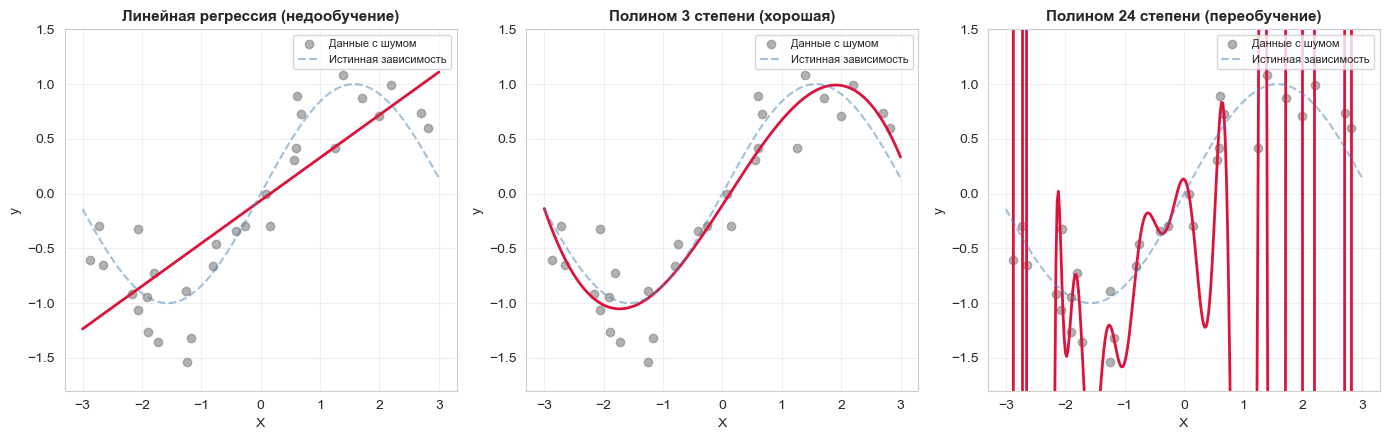

In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(42)

# Синтетические данные: зашумлённая синусоида
n = 30
X = np.sort(np.random.uniform(-3, 3, n)).reshape(-1, 1)
y_true = np.sin(X).ravel()
y = y_true + np.random.normal(0, 0.3, n)

# Три модели: недообученная (линейная), хорошая (полином 3 степени), переобученная (полином 20 степени)
models = [
    ("Линейная регрессия (недообучение)", 1),
    ("Полином 3 степени (хорошая)", 3),
    ("Полином 24 степени (переобучение)", 24)
]

plt.figure(figsize=(14, 4.5))

for i, (title, degree) in enumerate(models, 1):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y)
    X_test = np.linspace(-3, 3, 300).reshape(-1, 1)
    y_pred = model.predict(X_test)

    plt.subplot(1, 3, i)
    plt.ylim(-1.8, 1.5)
    plt.scatter(X, y, color='gray', alpha=0.6, label='Данные с шумом')
    plt.plot(X_test, y_pred, color='crimson', linewidth=2)
    plt.plot(X_test, np.sin(X_test).ravel(), '--', color='steelblue', alpha=0.5, label='Истинная зависимость')
    plt.title(title, fontsize=11, fontweight='bold')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Слева: линейная регрессия.** Прямая линия. Она даже не пытается повторить изгибы синусоиды. Ошибка на обучении большая — но и на новых данных она будет такой же большой. Это **недообучение**: модель слишком проста для задачи. В терминах машинного обучения у неё высокий bias (смещение). Она систематически ошибается.


**В центре: полином 3 степени.** Он неплохо повторяет волну. Не идеально — шум мешает. Но в целом похоже. Это **хорошая модель**: она не подстраивается под каждый шумовой выброс, но ловит основную закономерность. Она генерализует.


**Справа: полином 20 степени.** А тут весело. Модель так старалась угодить каждой точке, что нарисовала дикие изгибы между ними. На обучающих данных её ошибка близка к нулю. Но на реальных новых данных — полный провал. Это **переобучение**: модель запомнила шум, а не сигнал. У неё высокий variance (разброс). Она как тот студент, который пересдаёт экзамен четыре раза и каждый раз учит новый набор вопросов — но не понимает предмета.

### 1.2. Как понять, что модель врёт?

Золотое правило: **никогда не верьте метрике на обучающей выборке** (а вот о том, что такое метрики, обучающая и тестовая выборки, мы поговорим чуть позже, в §2 и §3). Если модель на обучении выдаёт идеальный результат, а на тесте — в разы хуже, значит, модель просто вызубрила ответы. Она не предсказывает — она воспроизводит.


Есть два главных врага генерализации:

- Переобучение — модель слишком сложная. Она подстроилась под шум. Симптом: отличная метрика на обучении, плохая — на тесте. Лечится: упрощением модели, регуляризацией, большим количеством данных.

- Недообучение — модель слишком простая. Она не улавливает закономерностей. Симптом: плохая метрика и на обучении, и на тесте. Лечится: усложнением модели, добавлением признаков, уменьшением регуляризации.

Модель должна обобщать, а не запоминать. Чтобы это проверить — нужно смотреть не на то, насколько хорошо она знает учебник, а на то, как она отвечает на новые вопросы. Для этого данные делят на обучение и тест — но об этом в следующем параграфе.

## § 2. Метрики регрессии

Итак, мы умеем писать модели. Мы написали модель, модель что-то предсказала. И теперь нам нужно понять: насколько сильно она ошиблась?

Для этого существуют метрики. Это числа, которые говорят нам: «Ошибка маленькая — модель хорошая» или «Ошибка огромная — модель никуда не годится». В этом параграфе мы разберём метрики для регрессии — то есть для задач, где мы предсказываем число (цену, температуру, время, возраст, зарплату), а не класс.

Допустим, у нас есть реальные значения (`y_true`) и предсказанные моделью значения (`y_pred`). Пока никакой модели нет — мы просто придумаем числа, чтобы понять, как работают метрики.

In [3]:
y_true = np.array([3.0, -0.5, 2.0, 7.0, 4.2, 5.1, 6.8, 1.3, 9.0, 2.5])
y_pred = np.array([2.5, 0.0, 2.1, 7.8, 4.0, 5.5, 7.0, 1.0, 8.5, 3.0])

comparison = pd.DataFrame({
    'y_true': y_true,
    'y_pred': y_pred,
    'error': y_true - y_pred
})
comparison

,y_true,y_pred,error
0,3.0,2.5,0.5
1,-0.5,0.0,-0.5
2,2.0,2.1,-0.1
3,7.0,7.8,-0.8
4,4.2,4.0,0.2
5,5.1,5.5,-0.4
6,6.8,7.0,-0.2
7,1.3,1.0,0.3
8,9.0,8.5,0.5
9,2.5,3.0,-0.5


Модель ошибается. Иногда на 0.1, иногда на 0.8. В среднем — вроде не катастрофа. Но как это «усреднить» правильно? Тут и начинаются танцы с бубном.



### 2.1. MAE (Mean Absolute Error) — средняя абсолютная ошибка

Интуитивно — самая  понятная метрика. Мы берём каждую ошибку, берём её по модулю (чтобы не было отрицательных значений), складываем и делим на количество наблюдений.
$$
{\rm MAE} = \frac{1}{N}\sum_{i=1}^N |y_i - y^*_i|
$$

In [4]:
mae_manual = np.mean(np.abs(y_true - y_pred))
print('MAE (ручной расчёт):', round(mae_manual, 4))


mae_sklearn = mean_absolute_error(y_true, y_pred)
print('MAE (sklearn):', round(mae_sklearn, 4))


MAE (ручной расчёт): 0.4
MAE (sklearn): 0.4


**Интерпретация:** «В среднем модель ошибается на 0.4 единицы». Если мы предсказываем цену кофе в рублях — то ошибка в 40 копеек. Если возраст в годах — то 0.4 года. Просто и понятно.

MAE — это хороший инструмент, который измеряет ошибки. Точный, честный и без каких-либо хитростей. Но он не умеет наказывать за большие ошибки сильнее, чем за маленькие.

### 2.2. MSE (Mean Squared Error) — средняя квадратичная ошибка

А вот MSE — это уже инструмент с характером. Он возводит ошибку в квадрат. Зачем? А вот зачем.


Если ошибка 0.5, то в квадрате — 0.25. Если ошибка 2.0, то в квадрате — 4.0. Ошибка выросла в 4 раза (с 0.5 до 2.0), но её квадрат вырос в 16 раз (с 0.25 до 4.0). Вот что значит «наказывать большие ошибки»: MSE заставляет разницу между «чуть-чуть ошибся» и «сильно ошибся» становиться не линейной, а квадратичной. Большие ошибки начинают доминировать в сумме.

Или проще, через пропорцию:

Ошибка 0.5 → вклад в MSE: 0.25.

Ошибка 1.0 → вклад в MSE: 1.0 (в 4 раза больше, хотя ошибка выросла только в 2 раза).

Ошибка 2.0 → вклад в MSE: 4.0 (в 16 раз больше, хотя ошибка выросла в 4 раза).


То есть MSE «ругается» не на абсолютную величину каждой ошибки, а на относительное усиление разрыва между маленькими и большими ошибками. Чем больше ошибка — тем непропорционально сильнее она входит в сумму:


$$
{\rm MSE} = \frac{1}{N}\sum_{i=1}^N (y_i - y^*_i)^2
$$

In [5]:
mse_manual = np.mean((y_true - y_pred) ** 2)
print('MSE (ручной расчёт):', round(mse_manual, 4))

mse_sklearn = mean_squared_error(y_true, y_pred)
print('MSE (sklearn):', round(mse_sklearn, 4))

MSE (ручной расчёт): 0.198
MSE (sklearn): 0.198


**Интерпретация:** «Средняя квадратичная ошибка — 0.198». Но что это значит в реальных единицах? Ничего. Потому что единицы измерения — в квадрате. Если мы предсказывали метры, то MSE — это квадратные метры (и пока все нормально), а если рубли, то — квадратные рубли, а такой единицы не существует.

Именно поэтому наряду c MSE используют RMSE.


### 2.3. RMSE (Root Mean Squared Error) — корень из средней квадратичной ошибки

Берём MSE и извлекаем квадратный корень, возвращаясь тем самым к исходным единицам измерения.
$$
{\rm RMSE} = \sqrt{{\rm MSE}}
$$

In [6]:
rmse_manual = np.sqrt(mse_manual)
print('RMSE (ручной расчёт):', round(rmse_manual, 4))

print('RMSE (sklearn): недоступно в старых версиях python')

RMSE (ручной расчёт): 0.445
RMSE (sklearn): недоступно в старых версиях python


**Интерпретация:** «В среднем модель ошибается на 0.458 единицы, но это — с учётом того, что большие ошибки наказываются сильнее».


Заметьте: RMSE (0.445) немного больше MAE (0.400). Это не случайно. RMSE всегда больше или равно MAE (большие ошибки наказываются сильнее). Если разница между ними большая — значит, в данных есть выбросы, на которых модель ошибается особенно сильно.

### 2.4. R² (коэффициент детерминации) — насколько модель лучше, чем константа

А теперь — метрика, которая стоит особняком. R² не говорит нам «на сколько единиц модель ошибается». Он говорит: «Насколько лучше наша модель предсказывает данные **по сравнению с самой тупой моделью в мире** — предсказанием среднего значения?»


Представьте, что мы предсказываем зарплату. Если у нас нет никаких данных, мы просто говорим: «Средняя зарплата по выборке — 50 тысяч рублей». А теперь мы строим модель. И она предсказывает зарплату на основе возраста, образования и опыта работы. Если R² = 0.75 — значит, модель сократила ошибку на 75% по сравнению с тупым предсказанием среднего.


Формула (осторожно, красиво):
$$
R^2 = 1 - \frac{S^*}{\overline{S}}
$$
где:
$$
S^*=\sum_{i=1}^{N}(y_i - y^*_i)^2
$$
 — сумма квадратов остатков (ошибка нашей модели),
$$
\overline{S}=\sum_{i=1}^{N}(y_i - \overline{y}_i)^2
$$
 — общая сумма квадратов (ошибка тупой модели, которая всегда предсказывает среднее).

In [7]:
S_star = np.sum((y_true - y_pred) ** 2)
S_line = np.sum((y_true - np.mean(y_true)) ** 2)
r2_manual = 1 - S_star / S_line
print('R2 (ручной расчёт):', round(r2_manual, 4))

r2_sklearn = r2_score(y_true, y_pred)
print('R2 (sklearn):', round(r2_sklearn, 4))

R2 (ручной расчёт): 0.9746
R2 (sklearn): 0.9746


Интерпретация: R² = 0.9746. Это означает, что наша модель объясняет 97.5% дисперсии (разброса) данных. Остальные 2.5% — это то, что модель не улавливает (шум, неучтённые факторы).


Диапазоны коэффицента детерминации:

- R² = 1.0 — идеальная модель (ошибка ноль).

- R² = 0.0 — модель не лучше, чем просто среднее.

- R² < 0.0 — модель **хуже, чем просто среднее** (такое бывает: это значит, что мы ошиблись с моделью где-то очень сильно).


Почему R² — это круто? Потому что он безразмерный. В отличие от MAE и RMSE, которые зависят от масштаба данных (ошибка в 500 рублей для чашки кофе — это катастрофа, а для квартиры — подарок), R² всегда от 0 до 1 (ну, ладно: не всегда, но почти всегда). Поэтому можно сравнивать модели на разных датасетах.

### 2.5. Зачем так много?

«А не проще ли всегда использовать R²?» — спросите вы. И будете по-своему правы. R² действительно удобен: он нормирован, понятен, позволяет сравнивать модели на разных задачах. Но у него есть недостаток: R² не говорит, на сколько именно единиц ошибается модель. Если бизнесу нужно знать «среднюю ошибку в рублях» — MAE или RMSE незаменимы.


Поэтому, как правило, считается всё. А дальше — выбирается то, что нужно для конкретной задачи. Для себя — R². Для отчёта заказчику — MAE. Для статьи в научный журнал — RMSE и R². А MSE — тоде для себя, но так, чтобы на корню убивать выбросы.

## §3. Train/Test — первый шаг к честности

Допустим, мы обучили модель. Она показала шикарный R² = 0.95 на тех данных, на которых училась. Мы рады. Мы счастливы. Мы уже мысленно покупаем яхту и увольняемся с работы.

А потом мы показываем нашей модели новые данные — и она начинает творить дичь. R² падает в ноль, а то и в минус. Что не так? А не так вот что: наша модель выучила шум. Она не поняла закономерностей — она просто запомнила ответы. Как студент, который вызубрил билеты, но не понимает предмета. На новых вопросах — у такого студента провал.

Это явление называется переобучение (overfitting). И бороться с ним просто — нужно разделить данные на две части: обучающую (train) и тестовую (test).


- **Обучающая выборка (train)** — на ней модель учится. Ищет закономерности, подгоняет коэффициенты, старается изо всех сил.


- **Тестовая выборка (test)** — это экзамен. Модель никогда не видела эти данные. Она показывает, насколько она действительно поняла закономерности, а не просто запомнила ответы.


И вот здесь возникает важнейшее правило, которое следует вбивать в головы студентам с первой же лекции.

#### Правило

*На тестовую выборку нельзя смотреть до финальной оценки модели. Никак. Совсем. Даже краем глаза. Даже «я просто посмотрю, что там за данные, я не буду подгонять модель». Врёшь. Будешь.*

В sklearn для разбиения данных этого есть замечательная функция `train_test_split`. Она делает ровно две вещи: 1) перемешивает данные и 2) режет их на две части в заданной пропорции. Обычно берут 70–80% на обучение и 20–30% на тест. Вот ее синтаксис:
```python
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
```
Параметр `random_state` фиксирует случайность, чтобы результаты можно было воспроизвести. Если его не указать (не обязательно указывать 42, можно указать любое число), каждый запуск будет давать новое разбиение, и мы никогда не сможем повторить эксперимент.

Дальше считаем метрики отдельно на трейне и отдельно на тесте. И если на трейне всё супер, а на тесте всё плохо — то модель переобучилась, и нужно что-то менять (вопрос — что именно? — это другой вопрос, и очень, кстати, непростой). А если те тесте все плохо, и на обучении не лучше — то модель не доучилась. И тоже надо что-то менять.

## §4. Регрессия. Пример на датасете кофейни «Кофе с Собой»

Давайте посмотрим, как эти метрики работают в реальной жизни. Загружаем данные, смотрим на них:

In [8]:
df = pd.read_csv('data/coffe2go.csv')
df

,hour,dayofweek,cust_dist,items_count,total_price,barista_exp,promo,rain,time_to_serve,good_review,repeat_visit
0,6,1,13.39,4,101.58,51,1,1,127,1,0
1,19,1,10.54,4,1351.93,58,0,1,131,1,0
2,14,1,4.03,2,535.46,34,1,0,47,1,1
3,10,3,14.01,2,536.09,59,0,0,40,1,0
4,7,2,2.02,7,419.32,21,1,1,244,0,1
...,...,...,...,...,...,...,...,...,...,...,...
4995,11,1,6.84,1,1177.36,51,0,0,30,1,0
4996,10,5,4.21,7,471.26,5,0,0,272,0,0
4997,14,1,2.24,8,1348.13,22,0,0,227,0,1
4998,15,3,13.72,6,200.00,9,0,0,219,0,0


#### Контекст
Сеть городских кофеен «Кофе с Собой» (Coffe2Go) хочет оптимизировать работу бариста и планирование закупок. Каждая продажа фиксируется в системе, и накоплено много данных.

#### Датасет

- hour — время суток (час, 0–23) (int),
- dayofweek — день недели	(0 (пн) – 6 (вс)) (int),
- cust_dist — расстояние до кофейни от места работы/дома клиента (0.5–15.0 (км)) (float),
- items_count — количество позиций в заказе (1–8)	(int),
- total_price — сумма чека (100–1500 (руб)) (float),
- barista_exp — стаж бариста, который принял заказ (1–60 (мес)) (int),
- promo — наличие акции (0 — нет, 1 — да) (int),
- rain — идёт ли дождь (0 — нет, 1 — да) (int).

#### Таргеты

- time_to_serve — время приготовления заказа (сек) (float)/ Непрерывная величина. Диапазон: 30–600 секунд. Зависит от числа позиций, стажа бариста, времени суток и погоды.

- good_review — высокий рейтинг отзыва (0/1) (int). Примерно 50/50. Клиенты склонны оставлять оценку 4–5 (1) или 1–3 (0) примерно с равной вероятностью. Ключевые влияющие признаки: время обслуживания, погода, наличие акции.

- repeat_visit — повторный визит в течение 7 дней (0/1) (int). Дисбаланс: около 70–80% клиентов не возвращаются в течение недели, 20–30% приходят снова. Важно для бизнеса: удержание клиента важнее привлечения нового. Поэтому модель должна вылавливать тех, кто скорее всего не вернётся, чтобы отправить им персональную скидку.

#### Бизнес-задачи

- Прогнозировать время приготовления `time_to_serve` — чтобы бариста могли планировать поток и не создавать очередей в час пик.

- Предсказывать `good_review` — чтобы понимать, какие факторы ведут к низкой оценке, и оперативно их исправлять.

- Предсказывать `repeat_visit` — чтобы выделять клиентов группы риска и мотивировать их вернуться через push-уведомления или скидки.

Категориальные таргеты мы отложим до следующего параграфа, а пока займемся непрерывным таргетом `time_to_serve`.

Делим признаки на предикторы и таргеты, а наблюдения — на обучающие и тестовые:

In [9]:
X = df.drop(columns = ['time_to_serve'])
y = df['time_to_serve']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Обучаем простую линейную регрессию (пусть будет бейзлайн, с которого мы начинаем):

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

И вычисляем метрики: сначала на обучающей выборке, потом — на тестовой.

In [11]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print("Train:")
print(f"MAE:  {mae_train:.2f}")
print(f"MSE:  {mse_train:.2f}")
print(f"RMSE: {rmse_train:.2f}")
print(f"R²:   {r2_train:.4f}")

print("\nTest:")
print(f"MAE:  {mae_test:.2f}")
print(f"MSE:  {mse_test:.2f}")
print(f"RMSE: {rmse_test:.2f}")
print(f"R²:   {r2_test:.4f}")

Train:
MAE:  14.56
MSE:  331.37
RMSE: 18.20
R²:   0.9409

Test:
MAE:  14.31
MSE:  321.44
RMSE: 17.93
R²:   0.9416


#### Замечание о сложности модели (точнее, о простоте)

Ну что мои внимательные читатели — не все, но некоторые из вас смогли заметить странную вещь: на тесте метрики получились даже лучше, чем на трейне. R² на тесте — 0.9416, а на трейне — 0.9409. Разница мизерная, но она есть, и она в пользу теста.

Обычно мы ожидаем обратного: модель на трейне показывает себя чуть лучше, чем на новых данных. Но здесь мы имеем дело с линейной регрессией. А это — самая простая, самая честная модель из всех возможных. У неё нет сложных изгибов, нет тысяч параметров, которые могут «запомнить» шум. Она просто проводит прямую линию (точнее, гиперплоскость) через облако точек.

И такая модель не может переобучиться в принципе. **Она слишком проста.** У неё нет «памяти» — она не способна запомнить каждый отдельный выброс. Всё, что она может — найти общее направление, общий тренд. Поэтому её результаты на трейне и на тесте почти одинаковы. А небольшие колебания — это просто случайность: какие именно точки попали в трейн, какие — в тест. Иногда тесту «везёт» чуть больше, иногда — трейну.

Запомните этот момент. Для сложных моделей — деревьев, бустингов, нейросетей — метрики на трейне почти всегда будут заметно выше, чем на тесте. И это нормально. Но если вы видите, что простая модель (например, линейная регрессия) вдруг показывает на тесте результат хуже, чем на трейне — скорее всего, вы просто неправильно разделили данные или в них есть какая-то систематическая ошибка. А если метрики почти совпадают или тест даже чуть лучше — значит, модель работает честно, без подгонки.

Это и есть генерализация в чистом виде.

## § 5. Метрики классификации

Итак, мы научились решать задачу регрессии и оценивать качество регрессионного прогноза. Но Data Science — это не только про числа. Огромный пласт задач — это задачи классификации, когда нужно отнести объект к одному из классов.

Хороший ли отзыв оставил клиент — или плохой? Будет ли транзакция мошеннической — или легитимной? Будет ли у пациента диагностировано заболевание — или нет?

Во всех этих случаях ответ — не число, а метка класса. И чтобы оценить, насколько хорошо наша модель справляется с угадыванием этой метки, нам нужны специальные метрики. Метрики регрессии (MAE, RMSE, R²) здесь не работают: ошибка в 0.3 не имеет смысла, когда ответ может быть только «да» или «нет».

Мы разберём пять основных метрик классификации, каждая из которых смотрит на задачу под своим углом: accuracy, precision, recall, F1-мера и ROC-AUC. Все они нужны, и все они немного врут — но если знать, как они устроены, вы сможете выбрать правильную метрику для вашей задачи.

Чтобы понять любую метрику классификации, нужно сначала разобраться, что такое матрица ошибок (confusion matrix). Это простая таблица 2×2, которая сравнивает предсказания модели с реальными значениями.

|  | Реально: Positive | Реально: Negative |
| --- | --- | --- |
| **Предсказано: Positive** | True Positive (TP) | False Positive (FP)  |
| **Предсказано: Negative** | False Negative (FN)  | True Negative (TN) |

Важно запомнить четыре клеточки. Всё остальное — это просто арифметика с ними.

In [12]:
y_true = np.array([1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0])
y_pred = np.array([1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0])

TP = np.sum((y_true == 1) & (y_pred == 1))
TN = np.sum((y_true == 0) & (y_pred == 0))
FP = np.sum((y_true == 0) & (y_pred == 1))
FN = np.sum((y_true == 1) & (y_pred == 0))

print("Ручной расчёт матрицы ошибок:")
print(f"TP = {TP}, TN = {TN}, FP = {FP}, FN = {FN}")
print(f"Матрица ошибок:\n  [TP={TP}, FP={FP}]\n  [FN={FN}, TN={TN}]")

Ручной расчёт матрицы ошибок:
TP = 4, TN = 5, FP = 1, FN = 2
Матрица ошибок:
  [TP=4, FP=1]
  [FN=2, TN=5]


Перед нами два вектора одинаковой длины, заполненные нулями и единицами. `y_true` — настоящие метки объектов (то, что мы знаем), `y_pred` — то, что предсказала модель. Мы вручную подсчитали, сколько раз модель угадала Positive, сколько раз ошиблась в обе стороны, и сколько раз верно сказала Negative. 

Заметьте: эта матрица — фундамент. Все метрики классификации, которые пойдут ниже, выводятся из этих четырёх чисел

### 5.1 Accuracy (доля правильных ответов)

Самая простая и самая коварная метрика.

$$
{\rm Accuracy} = \frac{{\rm TP} + {\rm TN}}{{\rm TP} + {\rm TN} + {\rm FP} + {\rm FN}}
$$

Это доля объектов, которые модель классифицировала верно, среди всех объектов. Просто и понятно. Если из 100 отзывов модель правильно угадала 90 — accuracy = 0.9.

Но есть одна ~~небольшая~~ большая проблема: accuracy не чувствует дисбаланс классов. 


Представьте задачу: выявить мошеннические транзакции. В реальности мошенничество встречается в 1 случае из 1000. Если ваша модель скажет «все транзакции легитимные», она ошибётся только в одной десятой процента случаев — accuracy будет 0.999. Отличный результат! Но модель абсолютно бесполезна: она не обнаружила ни одного мошенничества.

Для сбалансированных классов accuracy — хорошая, честная метрика. Но как только классы перекошены — начинаются проблемы. Мы вернёмся к этому вопросу чуть позже, на примере наших данных.

In [13]:
accuracy_manual = (TP + TN) / (TP + TN + FP + FN)
print(f"\nAccuracy (ручной расчёт): {accuracy_manual:.3f}")

accuracy_sklearn = accuracy_score(y_true, y_pred)
print(f"Accuracy (sklearn):        {accuracy_sklearn:.3f}")
print(f"Совпадают: {abs(accuracy_manual - accuracy_sklearn) < 1e-10}")


Accuracy (ручной расчёт): 0.750
Accuracy (sklearn):        0.750
Совпадают: True


Accuracy — самая простая метрика. В данном случае модель угадала 9 объектов из 12, получилось 0.75. Это неплохо, но давайте посмотрим на состав ошибок. У нас одно ложное срабатывание (FP=1) и два пропуска (FN=2) — accuracy скрывает, в какую сторону модель ошибается. А ведь цена этих ошибок может быть совершенно разной. Давайте разложим качество модели дальше.

### 5.2. Precision (точность)

Precision отвечает на вопрос: «Среди всего, что модель назвала положительным, сколько действительно положительно?»

$$
{\rm Precision} = \frac{{\rm TP}}{{\rm TP} + {\rm FP}}
$$

Если модель сказала «мошенничество» 10 раз, и 8 из них оказались правдой — precision = 0.8.

Precision важна, когда цена ложного срабатывания (FP) высока. Например, в спам-фильтре: если вы пометите важное письмо как спам — это катастрофа. Поэтому вы хотите, чтобы precision была высокой: пусть лучше модель пропустит немного спама (пропустит, а не отметит важное письмо ошибочно), чем ошибётся в другую сторону.

In [14]:
precision_manual = TP / (TP + FP)
print(f"\nPrecision (ручной расчёт): {precision_manual:.3f}")

precision_sklearn = precision_score(y_true, y_pred)
print(f"Precision (sklearn):        {precision_sklearn:.3f}")
print(f"Совпадают: {abs(precision_manual - precision_sklearn) < 1e-10}")

print(f"\nМодель предсказала Positive в {TP + FP} случаях, из них {TP} — верно.")
print(f"То есть, когда модель говорит 'Positive', она права в {precision_manual:.0%} случаев.")


Precision (ручной расчёт): 0.800
Precision (sklearn):        0.800
Совпадают: True

Модель предсказала Positive в 5 случаях, из них 4 — верно.
То есть, когда модель говорит 'Positive', она права в 80% случаев.


Precision говорит нам о «чистоте» положительных предсказаний. В нашем примере из 5 случаев, когда модель сказала «1», реально единицами оказались 4. То есть precision = 0.8. Довольно неплохо, но где-то модель всё-таки даёт ложные тревоги. Для некоторых задач (тот же спам-фильтр) это может быть критично — и мы тогда захотим поднять precision, пожертвовав чем-то другим.

### 5.3. Recall (полнота)

Recall отвечает на вопрос: «Среди всех реально положительных объектов сколько модель смогла найти?»

$$
{\rm Recall} = \frac{{\rm TP}}{{\rm TP} + {\rm FN}}
$$

Если в выборке было 100 мошеннических транзакций, а модель нашла 90 — recall = 0.9.

Recall важен, когда **цена пропуска цели (FN) высока**. Например, в медицинской диагностике: пропустить болезнь — страшнее, чем ошибочно заподозрить её у здорового человека (ложное срабатывание можно перепроверить, а пропущенную болезнь — уже не вернёшь).

In [15]:
recall_manual = TP / (TP + FN) if (TP + FN)
print(f"\nRecall (ручной расчёт): {recall_manual:.3f}")

recall_sklearn = recall_score(y_true, y_pred)
print(f"Recall (sklearn):        {recall_sklearn:.3f}")
print(f"Совпадают: {abs(recall_manual - recall_sklearn) < 1e-10}")

print(f"\nВсего реальных Positive: {TP + FN}. Модель нашла: {TP}.")
print(f"То есть модель обнаружила {recall_manual:.0%} всех реально положительных объектов.")


Recall (ручной расчёт): 0.667
Recall (sklearn):        0.667
Совпадают: True

Всего реальных Positive: 6. Модель нашла: 4.
То есть модель обнаружила 67% всех реально положительных объектов.


Recall — это про то, сколько целей мы не пропустили. В нашем примере реальных Positive было 6 (TP+FN=4+2), а модель увидела только 4. Два Positive она пропустила. Recall = 0.667. Неплохо, но если это медицинский тест — каждый пропуск может стоить жизни. Поэтому задачи с высокими требованиями к recall часто идут на компромисс: пусть лучше лишний раз перестрахуемся и получим больше ложных тревог, но ничего не пропустим.

#### Компромисс между precision и recall

Вот здесь начинается самое интересное. Precision и recall находятся в обратной зависимости. Повышая одно, мы почти всегда понижаем другое.

Представьте, что мы настраиваем порог классификации: модель выдает вероятность принадлежности к классу, а мы говорим: «всё, что выше 0.5 — Positive». Если мы опустим порог до 0.3, модель начнёт активнее назначать Positive. Recall вырастет (найдём больше реальных Positive), но precision упадёт (появится больше ложных срабатываний). Если поднимем порог до 0.8 — precision вырастет, но recall упадёт (станем слишком осторожными и пропустим много реальных Positive).

Этот компромисс — фундаментальное свойство любой модели классификации. Вы не можете получить идеальные 100% и по precision, и по recall одновременно. Вам всегда придётся выбирать, что важнее в вашей конкретной задаче.


### 5.4. F1-мера

Если хочется одной цифры, которая учитывает оба показателя (и precision, и recall), используют F1-меру. Это гармоническое среднее precision и recall:

$$
{\rm F1} = 2\cdot\frac{{\rm Precision}\cdot{\rm Recall}}{{\rm Precision} + {\rm Recall}}
$$


Метрика F1 наказывает за сильный дисбаланс между precision и recall. Если precision = 1.0, а recall = 0.1 — F1 будет 0.1. Если оба по 0.5 — F1 = 0.5. Если оба по 0.9 — F1 = 0.9. А вот если precision = 0.1, а recall = 0.9 — F1 будет 0.18 (дисбаланс наказывается). 


Она хороша, когда нам нужен баланс, и мы не можем выбрать, что важнее. Но помните: за этой одной цифрой теряется информация. F1 = 0.8 может получиться как при precision=0.9 и recall=0.73, так и при precision=0.73 и recall=0.9. Это два разных поведения модели, хотя F1 одинаковая.

In [16]:
f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual) \
            
print(f"\nF1 (ручной расчёт): {f1_manual:.3f}")

f1_sklearn = f1_score(y_true, y_pred)
print(f"F1 (sklearn):        {f1_sklearn:.3f}")
print(f"Совпадают: {abs(f1_manual - f1_sklearn) < 1e-10}")


F1 (ручной расчёт): 0.727
F1 (sklearn):        0.727
Совпадают: True


F1 даёт нам одну цифру вместо двух, но эта цифра достаточно умна, чтобы наказывать за сильный перекос.

Итак, мы разобрали четыре метрики, которые считаются из confusion matrix. Но есть одна метрика, которая стоит особняком — она не зависит от выбранного порога классификации. Это ROC-AUC. Поговорим о ней отдельно.

### 5.5. ROC-AUC (Receiver Operating Characteristic — Area Under Curve)

До этого момента все метрики (accuracy, precision, recall, F1) требовали, чтобы мы зафиксировали порог бинаризации: модель выдает вероятность, а мы говорим «всё, что выше 0.5 — Positive». Но что, если порог выбрать по-другому? Качество модели изменится.

ROC-AUC отвечает на вопрос: «А как бы вела себя модель, если бы мы перебрали все возможные пороги?» И выдаёт одно число — площадь под ROC-кривой.


ROC-кривая строится в координатах:

- По оси X откладывается FPR (False Positive Rate) — доля ложных срабатываний среди всех реальных Negative.

$$
{\rm FPR} = \frac{{\rm FP}}{{\rm FP} + {\rm TN}}
$$


- По оси Y откладывается TPR (True Positive Rate) — это наш знакомый recall.

$$ 
{\rm TPR} = \frac{{\rm TP}}{{\rm TP} + {\rm FN}} = {\rm Recall}
$$

Каждая точка на кривой соответствует одному значению порога. Чем ближе кривая к левому верхнему углу — тем лучше модель. Идеальная модель даёт AUC = 1.0. Модель, которая угадывает случайно — AUC = 0.5 (кривая совпадает с диагональю).

Если у нас только бинарные предсказания (0 и 1), то и порог менять нечего. Мы можем построить ROC-кривую только по одной точке (один порог — одна пара FPR, TPR). Это скучно и неинформативно. Но. Если у нас есть вероятности (y_prob), которые выдала модель до бинаризации — вот тогда мы можем менять порог и рисовать полноценную кривую.

Однако для раздела 3.1.5 мы пока остаёмся в рамках игрушечного примера с бинарными векторами — и используем sklearn, который всё равно посчитает AUC по одному порогу (но честно предупредит, что это неполноценно). А настоящую мощь ROC-AUC мы покажем в параграфе 3.2 на реальной модели

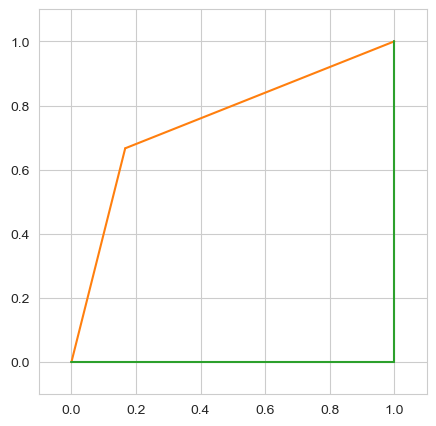

ROC AUC (ручной расчёт):  0.750
ROC AUC (sklearn):        0.750
Совпадают: True


In [17]:
y_true = np.array([1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0])
y_pred = np.array([1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0])

TP = np.sum((y_true == 1) & (y_pred == 1))
TN = np.sum((y_true == 0) & (y_pred == 0))
FP = np.sum((y_true == 0) & (y_pred == 1))
FN = np.sum((y_true == 1) & (y_pred == 0))

FPR = FP/(FP+TN)
TPR = TP/(TP+FN)

y_true =   np.array([1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0])
y_pred_2 = np.array([0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1])

TP_2 = np.sum((y_true == 1) & (y_pred_2 == 1))
TN_2 = np.sum((y_true == 0) & (y_pred_2 == 0))
FP_2 = np.sum((y_true == 0) & (y_pred_2 == 1))
FN_2 = np.sum((y_true == 1) & (y_pred_2 == 0))

FPR_2 = FP_2/(FP_2+TN_2)
TPR_2 = TP_2/(TP_2+FN_2)

plt.figure(figsize=(5, 5))

plt.xlim([-0.1,1.1])
plt.ylim([-0.1,1.1])

plt.plot([0, FPR], [0, TPR], '-', color='C1')
plt.plot([FPR, 1], [TPR, 1], '-', color='C1')

plt.plot([0, FPR_2], [0, TPR_2], '-', color='C2')
plt.plot([FPR_2, 1], [TPR_2, 1], '-', color='C2')

plt.show()

roc_auc_manual = 0.5 * (1 + TPR - FPR)

roc_auc_sklearn = roc_auc_score(y_true, y_pred)

print(f"ROC AUC (ручной расчёт):  {roc_auc_manual:.3f}")
print(f"ROC AUC (sklearn):        {roc_auc_sklearn:.3f}")
print(f"Совпадают: {abs(roc_auc_manual - roc_auc_sklearn) < 1e-10}")

Итак, у нас получился ROC-AUC = 0.75 для нашего игрушечного примера. Больше 0.5 — то есть модель лучше случайной. Но меньше 1.0 — не идеальна.

Важно понимать: в этом примере мы сжульничали — использовали бинарные предсказания, а не вероятности. ROC-кривая получилась всего из одной точки (плюс начальная и конечная). Это неполноценный ROC-AUC. Настоящая сила этой метрики раскрывается, когда у нас есть вероятности, и мы можем перебирать десятки и сотни порогов.

Тем не менее, даже такой урезанный ROC-AUC даёт нам одну полезную цифру, которая говорит: «модель лучше случайной».

Что дальше? В следующем параграфе мы возьмём настоящую модель, которая выдаёт вероятности, построим полноценную ROC-кривую и увидим, как выбор порога влияет на precision и recall. И тогда станет ясно, почему AUC — это настолько мощная метрика, что её любят и в соревнованиях на Kaggle, и в научных статьях.

## § 6. Бинарная классификация. Пример на датасете кофейни «Кофе с Собой»

Погнали.

In [18]:
df = pd.read_csv('data/coffe2go.csv')
df

,hour,dayofweek,cust_dist,items_count,total_price,barista_exp,promo,rain,time_to_serve,good_review,repeat_visit
0,6,1,13.39,4,101.58,51,1,1,127,1,0
1,19,1,10.54,4,1351.93,58,0,1,131,1,0
2,14,1,4.03,2,535.46,34,1,0,47,1,1
3,10,3,14.01,2,536.09,59,0,0,40,1,0
4,7,2,2.02,7,419.32,21,1,1,244,0,1
...,...,...,...,...,...,...,...,...,...,...,...
4995,11,1,6.84,1,1177.36,51,0,0,30,1,0
4996,10,5,4.21,7,471.26,5,0,0,272,0,0
4997,14,1,2.24,8,1348.13,22,0,0,227,0,1
4998,15,3,13.72,6,200.00,9,0,0,219,0,0


### 6.1. Предварительный анализ

Посмотрели. Что видим? А видим мы пять тысяч строк. Кофе — много. Кофе — разный. Хороший, плохой, злой. Как Клинт Иствуд. Наша задача — научиться отличать хороший от не очень, используя только те признаки, что у нас есть.

Смотрите. `total_price` — сотни, тысячи. `time_to_serve` — десятки, сотни. `barista_exp` — единицы, десятки. Вот они — признаки разного масштаба. Они как люди: одни громкие, другие тихие. И если мы сейчас скормим их kNN как есть, то `total_price` будет кричать громче всех, а `barista_exp` — стесняться в уголке. 

Это проблема. Мы о ней знаем. И мы её…

(барабанная дробь)

…пока проигнорируем. Потому что нормализация и стандартизация — это отдельная, большая и важная тема. Мы её разберём на следующих лекциях. А сейчас наша задача — научиться считать метрики и понимать, что они значат. Не отвлекаемся.

In [19]:
df.describe()

,hour,dayofweek,cust_dist,items_count,total_price,barista_exp,promo,rain,time_to_serve,good_review,repeat_visit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,11.503000,3.031400,7.780628,4.514800,793.246236,30.32400,0.304000,0.398400,143.532400,0.50000,0.250000
std,6.992408,2.001003,4.171999,2.298007,401.568355,17.28891,0.460029,0.489618,74.724315,0.50005,0.433056
min,0.000000,0.000000,0.500000,1.000000,100.010000,1.00000,0.000000,0.000000,30.000000,0.00000,0.000000
25%,5.000000,1.000000,4.267500,2.000000,444.682500,15.00000,0.000000,0.000000,80.000000,0.00000,0.000000
50%,12.000000,3.000000,7.815000,5.000000,790.765000,30.00000,0.000000,0.000000,141.000000,0.50000,0.000000
75%,18.000000,5.000000,11.340000,7.000000,1133.245000,45.00000,1.000000,1.000000,203.000000,1.00000,0.250000
max,23.000000,6.000000,15.000000,8.000000,1499.850000,60.00000,1.000000,1.000000,347.000000,1.00000,1.000000


Обратите внимание на `good_review`: среднее 0.5. Это значит, что классы сбалансированы. Хороших отзывов — половина, плохих — тоже половина. В такой ситуации accuracy — не враньё. Но об этом мы поговорим, когда будем разбирать метрики.

А теперь — картинка. Потому что глаза любят картинки.

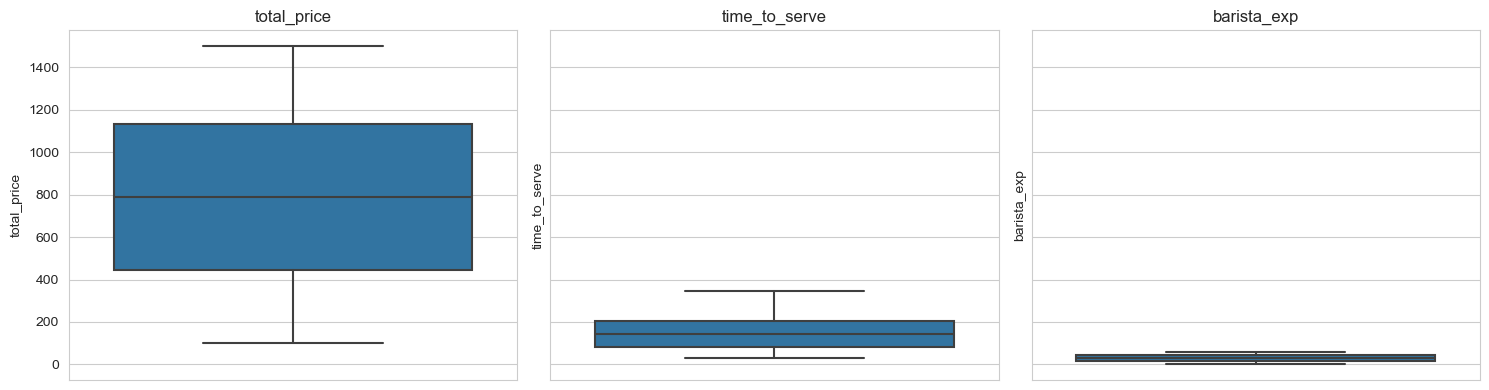

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
features = ['total_price', 'time_to_serve', 'barista_exp']
for i, feat in enumerate(features):
    sns.boxplot(y=df[feat], ax=axes[i])
    axes[i].set_title(feat)
plt.tight_layout()
plt.show()

### 6.2. Предикторы и таргет. Train и test

Целевая переменная у нас — `good_review`. Бинарная, сбалансированная. Забираем её в `y`.Всё остальное — в `X`. 

In [21]:
X = df.drop(columns = ['good_review'])
y = df['good_review']

Теперь разбиваем данные на train и test. Тут важно не накосячить. `test_size=0.3` — возьмём 30% под тест. `random_state=42` — чтобы при повторных запусках разбиение не изменялось. Ну и `stratify=y` — это святое. Чтобы пропорции классов в трейне и тесте остались такими же, как в исходном датасете.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Проверяем:

In [23]:
y_train.value_counts(normalize=True)

1    0.5
0    0.5
Name: good_review, dtype: float64

In [24]:
y_test.value_counts(normalize=True)

0    0.5
1    0.5
Name: good_review, dtype: float64

Баланс сохранился. Всё чисто. Можно работать дальше.


### 6.3. Обучение модели

Берём самоую простоую модель классификации. Модель — `KNeighborsClassifier`. Число соседей — `n_neighbors = 5`, по дефолту. Можно, конечно, поспорить про выбор k — и мы ещё вернёмся к этому вопросу. Но пока — пятёрка. Потому что так принято. Потому что это дефолт. Потому что мы просто хотим посмотреть, как оно работает, а не подбирать гиперпараметры с первой же секунды.

In [25]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

Готово, модель обучена. Что дальше? А дальше — самое интересное. Метрики, матрица ошибок, все эти TP, TN, FP, FN — с ними мы и будем разбираться дальше.

### 6.4. Матрица ошибок (Confusion Matrix)

Теперь мы хотим понять — а что cделала наша модель? Где угадала, где нет? Кого записала в хорошие, а кого — в плохие.

Для начала — получим прогнозы.

In [26]:
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

Теперь у нас есть ответы модели — и на трейне, и на тесте. Матрица ошибок — это таблица 2×2. Четыре клетки, в которых находятся счетчики ситуаций:

- TP (True Positive) — модель сказала «хороший», и это правда.

- TN (True Negative) — модель сказала «плохой», и это правда.

- FP (False Positive) — модель сказала «хороший», а на самом деле — плохой. Ложная тревога.

- FN (False Negative) — модель сказала «плохой», а на самом деле — хороший. Пропуск цели.


Можно посчитать руками. Можно — через sklearn. Покажем оба способа. Потому что мы — за понимание, а не за чёрный ящик.

На обучающей выборке:

In [27]:
TP_train = np.sum((y_train == 1) & (y_train_pred == 1))
TN_train = np.sum((y_train == 0) & (y_train_pred == 0))
FP_train = np.sum((y_train == 0) & (y_train_pred == 1))
FN_train = np.sum((y_train == 1) & (y_train_pred == 0))

print("Ручной расчёт матрицы ошибок на обучающей выборке:")
print(f"TP = {TP_train}, TN = {TN_train}, FP = {FP_train}, FN = {FN_train}")

cm_train_manual = np.array([[TP_train, FP_train],
                            [FN_train, TN_train]])
display(cm_train_manual)

print("Расчёт матрицы ошибок на обучающей выборке при помощи sklearn:")
cm_train_sklearn = confusion_matrix(y_train, y_train_pred)
cm_train_sklearn

Ручной расчёт матрицы ошибок на обучающей выборке:
TP = 1527, TN = 1541, FP = 209, FN = 223


array([[1527,  209],
       [ 223, 1541]], dtype=int64)

Расчёт матрицы ошибок на обучающей выборке при помощи sklearn:


array([[1541,  209],
       [ 223, 1527]], dtype=int64)

На тестовой выборке:

In [28]:
TP_test = np.sum((y_test == 1) & (y_test_pred == 1))
TN_test = np.sum((y_test == 0) & (y_test_pred == 0))
FP_test = np.sum((y_test == 0) & (y_test_pred == 1))
FN_test = np.sum((y_test == 1) & (y_test_pred == 0))

print("Ручной расчёт матрицы ошибок на тестовой выборке:")
print(f"TP = {TP_test}, TN = {TN_test}, FP = {FP_test}, FN = {FN_test}")

cm_test_manual = np.array([[TP_test, FP_test],
                            [FN_test, TN_test]])
display(cm_test_manual)

print("Расчёт матрицы ошибок на тестовой выборке при помощи sklearn:")
cm_test_sklearn = confusion_matrix(y_test, y_test_pred)
cm_test_sklearn

Ручной расчёт матрицы ошибок на тестовой выборке:
TP = 619, TN = 631, FP = 119, FN = 131


array([[619, 119],
       [131, 631]], dtype=int64)

Расчёт матрицы ошибок на тестовой выборке при помощи sklearn:


array([[631, 119],
       [131, 619]], dtype=int64)

Можно, кстати, визуализировать. Чтобы глазам было приятно.

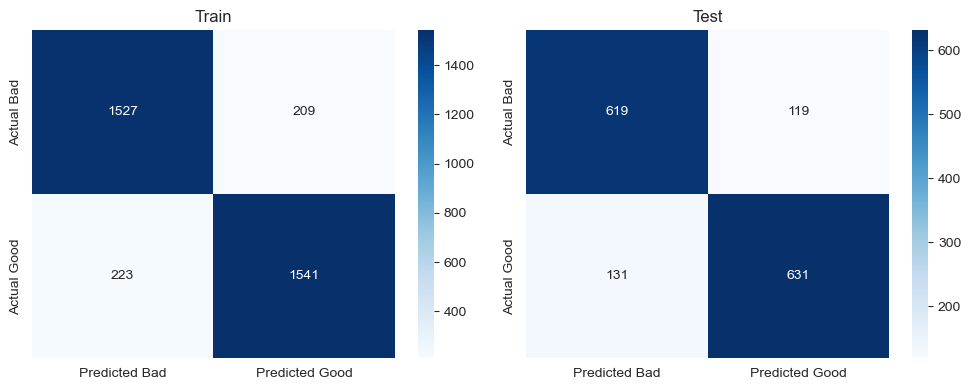

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(cm_train_manual, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Bad', 'Predicted Good'],
            yticklabels=['Actual Bad', 'Actual Good'],
            ax=axes[0])
axes[0].set_title('Train')

sns.heatmap(cm_test_manual, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Bad', 'Predicted Good'],
            yticklabels=['Actual Bad', 'Actual Good'],
            ax=axes[1])
axes[1].set_title('Test')

plt.tight_layout()
plt.show()


Темные позиции по главной диагонали и светлые по побочной — говорят о том, что модель обучилась хорошо.

### 6.5. Accuracy (точность)

Мы добрались до самой популярной, самой интуитивно понятной и — при неправильном использовании — самой опасной метрики.


Accuracy — это доля правильных ответов среди всех ответов. Формула до безобразия простая:

```python
accuracy = (TP + TN) / (TP + TN + FP + FN)
```
Или словами: «Сколько раз мы угадали — и нулей, и единиц — поделённое на всё, что было».

Сначала считаем руками. Берём нашу матрицу ошибок и просто складываем.

In [30]:
acc_train_manual = (TP_train + TN_train) / (TP_train + TN_train + FP_train + FN_train)
acc_test_manual = (TP_test + TN_test) / (TP_test + TN_test + FP_test + FN_test)

print(f'Accuracy train (manual): {acc_train_manual:.4f}')
print(f'Accuracy test (manual) : {acc_test_manual:.4f}')

Accuracy train (manual): 0.8766
Accuracy test (manual) : 0.8333


Теперь через библиотеку.

In [31]:
acc_train_sklearn = accuracy_score(y_train, y_train_pred)
acc_test_sklearn = accuracy_score(y_test, y_test_pred)

print(f'Accuracy train (sklearn): {acc_train_sklearn:.4f}')
print(f'Accuracy test (sklearn):  {acc_test_sklearn:.4f}')

Accuracy train (sklearn): 0.8766
Accuracy test (sklearn):  0.8333


Результат — тот же. Оно и понятно: accuracy_score делает ровно то же самое, только не просит вас руками вытаскивать числа из матрицы.

Смотрим и думаем.

На трейне — 87.66%. На тесте — 83.33%. Разница небольшая. Модель не переобучилась до состояния «я помню каждый чих», но и не блещет обобщением. Обычная история для kNN с пятёркой соседей без масштабирования.

Но! Есть важный комментарий, относительно которого я хочу, чтобы вы его запомнили. Вырежьте и повесьте над монитором.

#### Комментарий

*При сбалансированном таргете accuracy — адекватная метрика. Если бы классы были несбалансированы (например, 95% хороших отзывов и 5% плохих), accuracy была бы 95% при тупом предсказании «всегда 1». Модель, которая вообще ничему не научилась, показывала бы 95% точности. Красиво? Да. Полезно? Нет. Поэтому accuracy работает только при балансе классов.*


У нас баланс. Примерно 50 на 50. Поэтому наша accuracy в 83% — это честные 83%. Не фикция. Реальная доля правильных ответов. Но — забегая вперёд — даже при балансе accuracy не расскрывает всей истории. Она не знает, где мы ошиблись: с хорошими отзывами или с плохими. А это, как мы увидим дальше, может быть критично.

Но об этом — в следующих разделах.

### 6.6. Precision (точность прогнозов положительного класса)

Accuracy — это хорошо, но она не показывает, где мы косячим: с плюсом или с минусом (с 0 или с 1). Пора смотреть глубже. Переходим к Precision — к точности предсказаний положительного класса. Определение этой метрики:

```python
precision = TP / (TP + FP)
```

Смысл метрики, высказанный словами: «Из всех предсказанных нами "хороших отзывов" сколько оказались действительно хорошими?» Или, если ближе к нашей задаче: «Мы назвали кофе хорошим. Какова вероятность, что мы не ошиблись?»

Считаем. Сначала — руками. Из той самой матрицы ошибок.

In [32]:
precision_train_manual = TP_train / (TP_train + FP_train)
precision_test_manual = TP_test / (TP_test + FP_test)

print(f'Precision (manual, train): {precision_train_manual:.4f}')
print(f'Precision (manual, test): {precision_test_manual:.4f}')

Precision (manual, train): 0.8796
Precision (manual, test): 0.8388


То есть: из всех отзывов, которые наша модель назвала хорошими (TP+FP), хорошими на самом деле были лишь около 83.8%. Остальные 16.2% — это ложные тревоги.

Теперь — считаем через библиотеку. Чтобы не тратить время на ручные расчёты.

In [33]:
precision_train_sklearn = precision_score(y_train, y_train_pred)
precision_test_sklearn = precision_score(y_test, y_test_pred)

print(f'Precision (sklearn, train): {precision_train_sklearn:.4f}')
print(f'Precision (sklearn, test): {precision_test_sklearn:.4f}')

Precision (sklearn, train): 0.8796
Precision (sklearn, test): 0.8388


Precision важна тогда, когда цена ложноположительного срабатывания высока. Возьмём наш пример: если мы ошибочно назвали плохой кофе хорошим (FP), то что происходит? Клиент, увидев наш «хороший» прогноз, покупает. И получает разочарование. Репутация падает, клиент уходит, деньги теряются. Высокая цена ошибки? Ещё бы.

Поэтому в таких задачах мы часто хотим максимизировать precision. Чтобы быть уверенными: если уж мы сказали «хорошо», то это действительно хорошо. Мы готовы за это платить — например, более низким recall. Но об этом — дальше.

### 6.7. Recall (полнота)

Precision мы посмотрели. Теперь — другая сторона все той же медали.

Recall — она же полнота, она же чувствительность, она же True Positive Rate (TPR). Определение таково:

```python
recall = TP / (TP + FN)
```

Смысл, словами: «Из всех настоящих хороших отзывов, которые есть в данных — сколько мы нашли и правильно предсказали?»

Если precision отвечает на вопрос «когда я, модель, говорю "хорошо", можно ли мне верить?», то recall отвечает на вопрос «а не упустила ли я кого-то, кто реально хорош?». Разница между ними — в знаменателе. Там, где у precision были FP (наши ложные тревоги), у recall — FN (наши пропуски).

Считаем. Сначала руками.

In [34]:
recall_train_manual = TP_train / (TP_train + FN_train)
recall_test_manual = TP_test / (TP_test + FN_test)

print(f'Recall (manual, train): {recall_train_manual:.4f}')
print(f'Recall (manual, test): {recall_test_manual:.4f}')

Recall (manual, train): 0.8726
Recall (manual, test): 0.8253


Из всех отзывов, которые в реальности были хорошими (TP + FN), наша модель нашла только ~82%. Остальные 18% — ушли в FN. Модель сказала про них «плохой», а на самом деле — это был хороший кофе.

Теперь — считаем через sklearn:

In [35]:
recall_train_sklearn = recall_score(y_train, y_train_pred)
recall_test_sklearn = recall_score(y_test, y_test_pred)

print(f'Recall (sklearn, train): {recall_train_sklearn:.4f}')
print(f'Recall (sklearn, test): {recall_test_sklearn:.4f}')

Recall (sklearn, train): 0.8726
Recall (sklearn, test): 0.8253


Совпало. Отлично.

Recall важен, когда цена ложноотрицательного срабатывания высока. Применительно к нашей задаче: представьте, что мы пропустили хороший отзыв. Модель сказала «плохой», а кофе на самом деле был отличным. Клиент остался без комплимента, без скидки, без чувства, что его оценили. Что дальше? Он просто не вернётся. Потенциальный лояльный покупатель — потерян.

И это не единственный пример. В медицине recall — это способность не пропустить болезнь. В поиске — не упустить релевантный документ. В антифроде — не проморгать мошенническую транзакцию. Если преступник остался на свободе — это FN системы правосудия. Если больной не получил лечение — это FN диагноста.


Когда FN дороже FP — мы гонимся за recall. У нас — recall совсем даже неплохой: 0.82. Но если подумать, мы теряем 1 из 5 хороших отзывов. Это много. Если бы бизнес-задача была «не упустить ни одного довольного клиента», такой recall — был бы провалом. Но если задача — «не ошибиться в предсказании хорошего кофе, чтобы клиент не разочаровался», то мы бы пожертвовали recall ради precision.

Выбор — всегда за бизнесом.

### 6.8. F1-мера

Мы посмотрели precision. Посмотрели recall. И теперь перед нами классический выбор: что важнее — не пропустить плохих в состав хороших (precision) или не принять хороших за плохих (recall)?

Ответ бизнеса: «И то, и другое, начальник».

И вот тут на сцену выходит F1-мера — метрика, которая пытается усидеть на двух стульях сразу. И, что удивительно, у неё это неплохо получается. Определение: F1 — это гармоническое среднее precision и recall. Формула:

```python
F1 = 2 * (precision * recall) / (precision + recall)
```

Почему гармоническое, а не арифметическое? Потому что гармоническое среднее беспощадно к дисбалансу. Если precision = 1.0, а recall = 0.0, то арифметическое среднее даст 0.5 — и это будет ложное успокоение. Гармоническое среднее в той же ситуации даст 0.0. Потому что если один из показателей упал в ноль — всё, ты ничего не стоишь. F1 тебя не пожалеет.

Считаем. Сначала вручную.

In [36]:
f1_train_manual = 2*(precision_train_manual*recall_train_manual)/(precision_train_manual + recall_train_manual)
f1_test_manual = 2*(precision_test_manual*recall_test_manual)/(precision_test_manual + recall_test_manual)

print(f'f1 (manual, train): {f1_train_manual:.4f}')
print(f'f1 (manual, test): {f1_test_manual:.4f}')

f1 (manual, train): 0.8761
f1 (manual, test): 0.8320


Через sklearn:

In [37]:
f1_train_sklearn = f1_score(y_train, y_train_pred)
f1_taes_sklearn = f1_score(y_test, y_test_pred)

print(f'F1 (sklearn, train): {f1_train_sklearn:.4f}')
print(f'F1 (sklearn, test): {f1_taes_sklearn:.4f}')

F1 (sklearn, train): 0.8761
F1 (sklearn, test): 0.8320


Совпало. Хорошо.

В нашем случае precision и recall практически равны между собой (precision=0.8253, recall= 0.8388). Поэтому их среднее гармоническое мало отличается от среднего арифметического. Но если бы между ними была значительная разница, то перекос был бы в сторону меньшего числа.

F1 полезна, когда нужно сбалансировать precision и recall. Если одна из этих метрик резко падает, метрика F1 это немедленно отражает. Она не даёт вам успокоиться на мысли «ну, precision отличный, а recall — да ладно, подумаешь». Нет, F1 скажет: «У тебя recall упал — значит, ты плохо работаешь, даже если precision красивый».

Поэтому F1 — хороший выбор, когда:

- Классы сбалансированы (а у нас — да, 50/50).

- Нет явного приоритета между precision и recall (а у нас — есть, но для демонстрации мы пока берём баланс).

- Нужна одна метрика, чтобы оценить модель «в целом».

Для нашей модели на тесте F1 = 0.8320. Средненько. Модель не провалилась, но и не блещет. Дальше мы посмотрим, можно ли улучшить эту цифру за счёт настройки порога.

### 6.9. Влияние порога бинаризации на Accuracy, Precision, Recall и F1

До этого момента мы работали с жёсткими предсказаниями модели: `predict()` выдал 0 или 1, и мы считали метрики. Всё честно. Но kNN, как и многие другие классификаторы, умеет выдавать вероятности — степень уверенности в том, что объект принадлежит к классу 1.


Метод `predict_proba()` возвращает массив размером (`n_samples`, `n_classes`). 

In [38]:
y_test_pred_proba = knn.predict_proba(X_test)
y_test_pred_proba[:10]

array([[1. , 0. ],
       [0.2, 0.8],
       [0. , 1. ],
       [0.6, 0.4],
       [0. , 1. ],
       [0.4, 0.6],
       [0.2, 0.8],
       [0.8, 0.2],
       [1. , 0. ],
       [0.8, 0.2]])

Второй столбец — вероятность класса 1 («хороший отзыв»).


По умолчанию predict() переводит эти вероятности в бинарный класс с порогом 0.5: если вероятность >= 0.5 → класс 1, иначе → класс 0. Но кто сказал, что 0.5 — это оптимальный порог? Давайте посмотрим.

Создадим цикл по порогам от 0 до 1 с шагом 0.05. Для каждого порога переведём вероятности в классы и посчитаем accuracy, precision, recall и F1.

In [39]:
# Получаем вероятности для теста
y_test_pred_proba = knn.predict_proba(X_test)[:, 1]

# Создаём список порогов от 0 до 1 с шагом 0.05
thresholds = np.arange(0, 1.05, 0.05)

# Списки для хранения метрик
precisions = []
recalls = []
f1_scores = []
accuracies = []

for t in thresholds:
    # Переводим вероятности в классы по порогу t
    y_test_pred_t = (y_test_pred_proba >= t).astype(int)

    # Считаем метрики
    precisions.append(precision_score(y_test, y_test_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_test_pred_t))
    f1_scores.append(f1_score(y_test, y_test_pred_t, zero_division=0))
    accuracies.append(accuracy_score(y_test, y_test_pred_t))

# Смотрим результат для нескольких порогов
for i in range(0, len(thresholds), 5):
    print(f'Порог {thresholds[i]:.2f}: Precision={precisions[i]:.3f}, '
          f'Recall={recalls[i]:.3f}, F1={f1_scores[i]:.3f}, Accuracy={accuracies[i]:.3f}')

Порог 0.00: Precision=0.500, Recall=1.000, F1=0.667, Accuracy=0.500
Порог 0.25: Precision=0.765, Recall=0.913, F1=0.833, Accuracy=0.817
Порог 0.50: Precision=0.839, Recall=0.825, F1=0.832, Accuracy=0.833
Порог 0.75: Precision=0.884, Recall=0.693, F1=0.777, Accuracy=0.801
Порог 1.00: Precision=0.944, Recall=0.513, F1=0.665, Accuracy=0.741


Уже видно главное: при пороге 0.25 мы находим 91% хороших отзывов (recall = 0.913), но среди предсказанных «хороших» только 76% действительно хорошие (precision = 0.765). При пороге 0.75 — наоборот: precision взлетает до 0.884, но recall падает до 0.693.

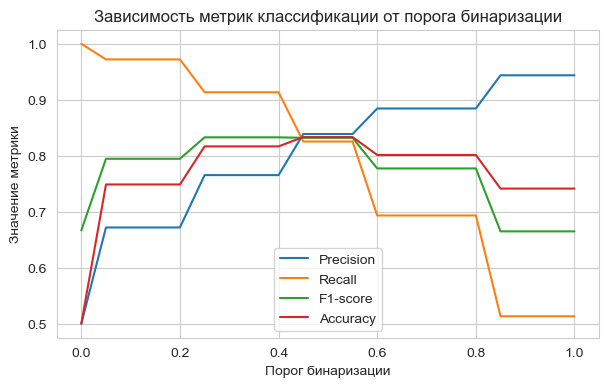

In [40]:
plt.figure(figsize=(7, 4))
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, f1_scores, label='F1-score')
plt.plot(thresholds, accuracies, label='Accuracy')
plt.xlabel('Порог бинаризации')
plt.ylabel('Значение метрики')
plt.title('Зависимость метрик классификации от порога бинаризации')
plt.legend()
plt.grid(True)
plt.show()

На графике мы видим четыре кривые. При пороге 0 точность классификации (accuracy) падает до 50% — потому что модель предсказывает всем класс 1, а хороших отзывов в тесте ровно половина. Precision при этом равен 0.5 (доля хороших среди всех предсказанных «хороших»), а recall = 1.0 (мы нашли все хорошие отзывы — потому что назвали все отзывы хорошими).

По мере роста порога precision растёт, recall падает. F1 достигает максимума где-то около порога 0.5-0.55 — и это не случайно. Accuracy тоже достигает пика около 0.5-0.55, потому что классы сбалансированы.

>#### Вопрос
Почему при t=1 метрика accuracy снижается, но не до 0.5, а лишь до 0.75?

#### Комментарий

Чем выше порог — тем выше precision (мы строже), но ниже recall. Выбор порога зависит от бизнес-задачи.


Давайте примерим это на наш кофе:

- Если нам важно не ошибиться с «плохим» кофе — то есть мы боимся назвать плохой кофе хорошим и тем самым рекомендовать его клиенту. В этом случае мы ставим высокий порог (например, 0.75). Да, мы пропустим много хороших отзывов (recall упадёт), но зато те, которые мы назовём хорошими — будут действительно хороши. Клиент не разочаруется.

- Если нам важно не пропустить «хороший» кофе — например, мы хотим собрать все положительные отзывы для анализа, чтобы понять, что мы делаем правильно. Тогда мы ставим низкий порог (например, 0.25). Да, среди собранного будет много «шума» (низкий precision), зато мы не упустим ни одного реально хорошего отзыва.

- Если нам нужен баланс — например, мы ограничены в ресурсах на проверку каждого предсказания. Тогда берём порог, при котором F1 максимален. В нашем случае это около 0.5-0.55.



#### Вывод

Все метрики, которые мы считали до этого — accuracy, precision, recall, F1 — зависят от выбранного порога бинаризации. При одном пороге модель может казаться отличной, при другом — провальной. Их нельзя рассматривать как «абсолютные» характеристики модели.

Нужна метрика, которая оценивает модель в целом, вне зависимости от того, какой порог мы потом выберем. Метрика, которая показывает, насколько хорошо модель умеет ранжировать объекты: ставить «хорошие» отзывы выше «плохих». И эта метрика — ROC-AUC.

Переходим к ней.

### 11. ROC-AUC (площадь под ROC-кривой)

До этого мы считали метрики, которые зависят от порога. Хороший порог выбрал — молодец. Плохой — провал. Но что, если мы хотим оценить модель саму по себе, без привязки к тому, какой порог мы потом выберем для продакшена?

Для этого есть ROC-AUC. ROC-кривая (Receiver Operating Characteristic) — это график зависимости TPR (True Positive Rate, он же recall) от FPR (False Positive Rate). Напоминаю:

```python
TPR = TP / (TP + FN) 
```
— доля правильно предсказанных положительных объектов среди всех реально положительных. Мы уже знаем это как recall.

```python
FPR = FP / (FP + TN) 
```
— доля ложно предсказанных положительных среди всех реально отрицательных. То есть, насколько часто мы «бьём тревогу» там, где её не нужно.

Идеальный классификатор: TPR = 1, FPR = 0 (левый верхний угол). Случайное угадывание: TPR = FPR (диагональ). Чем ближе кривая к левому верхнему углу — тем лучше модель разделяет классы.

Строим ROC-кривую. Сначала вручную.

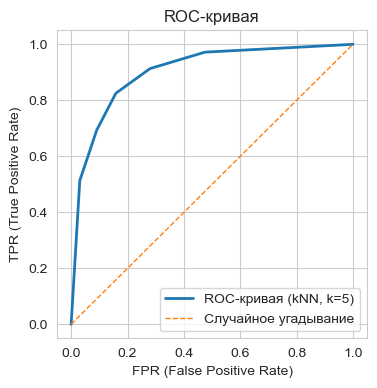

In [41]:
y_test_proba = knn.predict_proba(X_test)[:, 1]

thresholds_roc = np.linspace(0, 1.01, 100)
tpr_list = []
fpr_list = []

for t in thresholds_roc:
    y_pred_t = (y_test_proba >= t).astype(int)

    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    tn = ((y_pred_t == 0) & (y_test == 0)).sum()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    tpr_list.append(tpr)
    fpr_list.append(fpr)

plt.figure(figsize=(4, 4))

plt.grid(True)

plt.plot(fpr_list, tpr_list, label='ROC-кривая (kNN, k=5)', lw=2)
plt.plot([0, 1], [0, 1], '--', label='Случайное угадывание', lw=1)

plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate)')
plt.title('ROC-кривая')

plt.legend()

plt.show()


А теперь — при помощи методов sklearn:

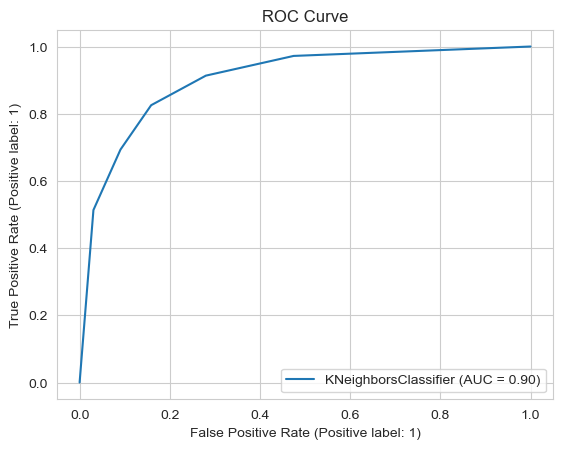

In [42]:
RocCurveDisplay.from_estimator(knn, X_test, y_test)
plt.title("ROC Curve")
plt.show()

Получилась, разумеется та же самая кривая. Правда график — неуправляемый. Поэтому использовать этот метод для публикаций или презентаций — это плохая идея. Но для того, чтобы быстро взгянуть на ROC-кривую (а заодно и на значение метрики) — самое то.

Метрика ROC-AUC — это площадь под ROC-кривой. AUC (Area Under Curve) — численная характеристика ROC-кривой, ее значение лежит от 0 до 1:

- 0.5 — случайное угадывание (кривая совпадает с диагональю).

- 1.0 — идеальный классификатор (кривая упирается в левый верхний угол).

- Чем ближе к 1 — тем лучше.

Считаем вручную (метод трапеций) и через sklearn:

In [43]:
roc_auc_manual = -np.trapz(tpr_list, fpr_list)
roc_auc_sklearn = roc_auc_score(y_test, y_test_proba)

print(f'AUC (ручной подсчёт): {roc_auc_manual:.4f}')
print(f'AUC (sklearn): {roc_auc_sklearn:.4f}')

AUC (ручной подсчёт): 0.9027
AUC (sklearn): 0.9027


>#### Вопрос
Почему `np.trapz` дал отрицательный результат?

#### Комментарий

ROC-AUC не зависит от выбора порога. Почему? Потому что мы строим кривую по всем возможным порогам сразу. AUC оценивает способность модели ранжировать объекты: насколько хорошо модель ставит «хорошие» отзывы выше «плохих».

Это метрика качества ранжирования, а не качества прогноза. Другими словами, если AUC = 0.9, это значит, что случайно выбранный хороший отзыв будет ранжирован выше случайно выбранного плохого в 90% случаев.

Именно поэтому ROC-AUC — стандартный инструмент для сравнения разных моделей: она не зависит ни от порога, ни от баланса классов (в отличие от accuracy).

## Домашнее задание

>#### Задание
Вычислите метрики классификации для модели, которая прогнозирует признак `repeat_visit`. Имейте в виду, что на этот раз признак не сбалансирован по классам.

In [44]:
# Код

Порог 0.00: Precision=0.500, Recall=1.000, F1=0.667, Accuracy=0.500, ROC-AUC=0.500
Порог 0.25: Precision=0.765, Recall=0.913, F1=0.833, Accuracy=0.817, ROC-AUC=0.817
Порог 0.50: Precision=0.839, Recall=0.825, F1=0.832, Accuracy=0.833, ROC-AUC=0.833
Порог 0.75: Precision=0.884, Recall=0.693, F1=0.777, Accuracy=0.801, ROC-AUC=0.801
Порог 1.00: Precision=0.944, Recall=0.513, F1=0.665, Accuracy=0.741, ROC-AUC=0.741


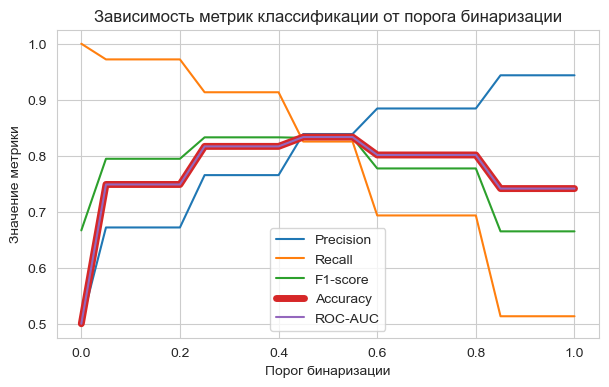

In [75]:
# Получаем вероятности для теста
y_test_pred_proba = knn.predict_proba(X_test)[:, 1]

# Создаём список порогов от 0 до 1 с шагом 0.05
thresholds = np.arange(0, 1.05, 0.05)

# Списки для хранения метрик
precisions = []
recalls = []
f1_scores = []
accuracies = []
roc_auc = [] 

for t in thresholds:
    # Переводим вероятности в классы по порогу t
    y_test_pred_t = (y_test_pred_proba >= t).astype(int)

    # Считаем метрики
    precisions.append(precision_score(y_test, y_test_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_test_pred_t))
    f1_scores.append(f1_score(y_test, y_test_pred_t, zero_division=0))
    accuracies.append(accuracy_score(y_test, y_test_pred_t))
    roc_auc.append(roc_auc_score(y_test, y_test_pred_t))

# Смотрим результат для нескольких порогов
for i in range(0, len(thresholds), 5):
    print(f'Порог {thresholds[i]:.2f}: Precision={precisions[i]:.3f}, '
          f'Recall={recalls[i]:.3f}, F1={f1_scores[i]:.3f}, Accuracy={accuracies[i]:.3f}, '
          f'ROC-AUC={roc_auc[i]:.3f}')

plt.figure(figsize=(7, 4))
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, f1_scores, label='F1-score')
plt.plot(thresholds, accuracies, lw= 5, label='Accuracy')
plt.plot(thresholds, roc_auc, label='ROC-AUC')
plt.xlabel('Порог бинаризации')
plt.ylabel('Значение метрики')
plt.title('Зависимость метрик классификации от порога бинаризации')
plt.legend()
plt.grid(True)
plt.show()

In [70]:
# Формируем датафрейм из истинных меток на тесте и вероятностей их принадлежности классу 1, который вернула модель.
df_ra = pd.DataFrame()
df_ra['y_true'] = y_test
df_ra = df_ra.reset_index(drop=True)
df_ra['y_score'] = y_test_proba

# Берем локализацию для всех единичных меток
df_ra_1 = df_ra.loc[df_ra['y_true'] == 1]
df_ra_1 = df_ra_1.reset_index(drop=True)

# Берем локализацию для всех нулевых меток
df_ra_0 = df_ra.loc[df_ra['y_true'] == 0]
df_ra_0 = df_ra_0.reset_index(drop=True)

# Подсчитываем число ситуаций, когда вероятность единичной метки находится в "правильном" соотношении 
# с вероятностью нулевой метки (при этом учитываем возможность точного равенства).
count = 0
for a in df_ra_1['y_score']:
    for b in df_ra_0['y_score']:
        if a>b:
            count=count+1
        elif a==b:
            count=count+0.5

# Берем отношение найденного числа к общему коничеству пар (единичная метка, нулевая метка)
# И проверяем равенство метрик. Да. Это действительно ROC-AUC, который посчитал sklearn.
round(count/(len(df_ra_1)*len(df_ra_0)), 4) == round(roc_auc_score(y_test, y_test_proba), 4)

True